In [11]:
import pandas as pd
import numpy as np

# 1. Mindkét nyers fájl beolvasása
df1 = pd.read_csv('../data/raw/CPU_benchmark_v4.csv')

def get_stats(df, name):
    # Hiányzó értékek (NaN)
    null_counts = df.isnull().sum()
    # Nulla értékek (csak numerikus oszlopoknál releváns)
    zero_counts = (df == 0).sum()

    stats = pd.DataFrame({
        'Hiányzó (NaN)': null_counts,
        'Nulla érték (0)': zero_counts
    })
    print(f"\n--- {name} statisztikák ---")
    print(stats)
    return stats

# Megjelenítés
stats1 = get_stats(df1, "CPU_benchmark_v4")


--- CPU_benchmark_v4 statisztikák ---
             Hiányzó (NaN)  Nulla érték (0)
cpuName                  0                0
price                 1858                0
cpuMark                  0                0
cpuValue              1858                0
threadMark               0                0
threadValue           1858                0
TDP                    685                0
powerPerf              685                0
cores                    0                0
testDate                 0                0
socket                   0                0
category                 0                0


--- Price korrelációk (One-Hot) ---
price          1.000000
cores          0.767044
cpuMark        0.692600
TDP            0.562841
testDate       0.331479
threadMark     0.253788
cpuValue      -0.232707
threadValue   -0.310359
Name: price, dtype: float64

--- TDP korrelációk (One-Hot) ---
TDP            1.000000
cores          0.664270
cpuMark        0.657544
price          0.562841
threadMark     0.349236
testDate       0.117902
cpuValue       0.097911
threadValue   -0.142167
Name: TDP, dtype: float64


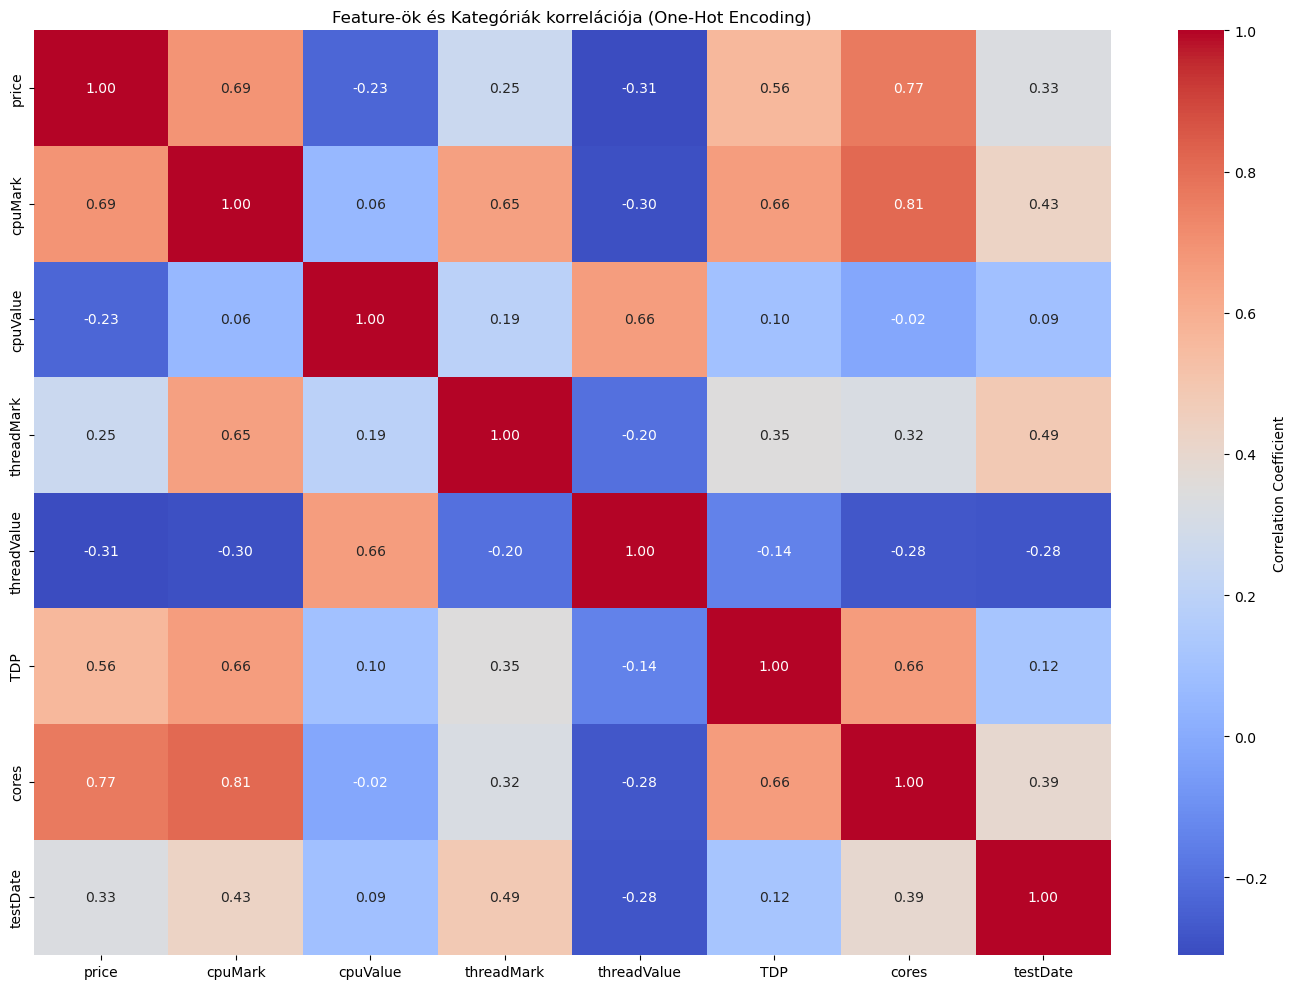

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# Másolat készítése és One-Hot Encoding alkalmazása
df_corr_analysis = pd.get_dummies(df1, columns=['category'], prefix='cat')

# Csak a numerikus oszlopok kiválasztása (az új dummy oszlopokkal együtt)
numeric_df = df_corr_analysis.select_dtypes(include=[np.number])

# Korrelációs mátrix kiszámítása
corr_matrix = numeric_df.corr()

# Price korrelációk
price_corr = corr_matrix['price'].sort_values(ascending=False)
print('--- Price korrelációk (One-Hot) ---')
print(price_corr)

# TDP korrelációk
tdp_corr = corr_matrix['TDP'].sort_values(ascending=False)
print('\n--- TDP korrelációk (One-Hot) ---')
print(tdp_corr)

# Vizualizáció hőtérképpel (csak a legfontosabb oszlopokra szűrve a jobb olvashatóságért)
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Feature-ök és Kategóriák korrelációja (One-Hot Encoding)')
plt.tight_layout()
plt.show()

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np

# Adatok elokeszitese - a price-t teljesen kihagyjuk
features = ['cores', 'cpuMark', 'threadMark', 'category', 'testDate']
df_reg = df1.dropna(subset=['TDP'] + features).copy()

y = df_reg['TDP']
X = pd.get_dummies(df_reg[features], columns=['category'])

# Tanito es teszt halmazok
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5 kulonbozo modell definialasa
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=10.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42)
}

results = []

for name, model in models.items():
    # Tanitas
    model.fit(X_train, y_train)
    # Predikcio
    y_pred = model.predict(X_test)
    # Metrikak
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    results.append({'Modell': name, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})
    

# Eredmenyek megjelenitese
results_df = pd.DataFrame(results)
display(results_df)

,Modell,RMSE,MAE,R2 Score
0,Linear,25.183460,17.830923,0.748229
1,Ridge,25.192529,17.839514,0.748048
2,Lasso,25.259531,17.929500,0.746706
3,ElasticNet,25.460296,18.085461,0.742663
4,RandomForest,21.903060,14.454576,0.809548


In [14]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

# 1. Előkészítés: Feature-ök meghatározása
features = ['cores', 'cpuMark', 'threadMark', 'category', 'testDate']
df_full = df1.copy()

# Tanító készlet (ahol van TDP)
df_train = df_full.dropna(subset=['TDP'] + features)
X_train = pd.get_dummies(df_train[features], columns=['category'])
y_train = df_train['TDP']

# A legjobb modell (Random Forest) tanítása a teljes elérhető adaton
final_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

# 2. Predikció: Azok a sorok, ahol hiányzik a TDP, de a többi adat megvan
df_missing = df_full[df_full['TDP'].isnull() & df_full[features].notnull().all(axis=1)].copy()

if not df_missing.empty:
    X_missing = pd.get_dummies(df_missing[features], columns=['category'])
    # Biztosítjuk az oszlopok egyezőségét
    X_missing = X_missing.reindex(columns=X_train.columns, fill_value=0)

    preds = final_model.predict(X_missing)
    df_full.loc[df_missing.index, 'TDP_predicted'] = preds

# Kombinált oszlop létrehozása
df_full['TDP_final'] = df_full['TDP'].fillna(df_full['TDP_predicted'])

print(f"Eredetileg hiányzó TDP: {df1['TDP'].isnull().sum()}")
print(f"Random Forest-tel pótolt: {df_full['TDP_predicted'].notnull().sum()}")

display(df_full[['cpuName', 'TDP', 'TDP_predicted', 'TDP_final']].head(10))



Eredetileg hiányzó TDP: 685
Random Forest-tel pótolt: 685


,cpuName,TDP,TDP_predicted,TDP_final
0,AMD Ryzen Threadripper PRO 5995WX,280.0,NaN,280.00
1,AMD EPYC 7763,280.0,NaN,280.00
2,AMD EPYC 7J13,NaN,250.45,250.45
3,AMD EPYC 7713,225.0,NaN,225.00
4,AMD Ryzen Threadripper PRO 3995WX,280.0,NaN,280.00
5,AMD Ryzen Threadripper 3990X,280.0,NaN,280.00
6,AMD Ryzen Threadripper PRO 5975WX,280.0,NaN,280.00
7,AMD EPYC 7B13,NaN,240.95,240.95
8,AMD EPYC 7643,225.0,NaN,225.00
9,AMD EPYC 7702,200.0,NaN,200.00


In [15]:
df_final_export = df_full.copy()
df_final_export['TDP'] = df_final_export['TDP_final'].round(2)

# PowerPerf numerikussá alakítása és számítása
df_final_export['powerPerf'] = pd.to_numeric(df_final_export['powerPerf'].astype(str).str.replace(',', ''), errors='coerce')
df_final_export['powerPerf'] = df_final_export['powerPerf'].fillna(df_final_export['cpuMark'] / df_final_export['TDP']).round(2)

# Szükségtelen oszlopok törlése és mentés
df_final_export.drop(columns=['TDP_predicted', 'TDP_final']).to_csv('../data/processed/CPU_benchmark_v4_TDP.csv', index=False)

print("A kiegészített adathalmaz elmentve.")
display(df_final_export[['cpuName', 'cpuMark', 'TDP', 'powerPerf']].head())

A kiegészített adathalmaz elmentve.


,cpuName,cpuMark,TDP,powerPerf
0,AMD Ryzen Threadripper PRO 5995WX,108822,280.00,388.65
1,AMD EPYC 7763,88338,280.00,315.49
2,AMD EPYC 7J13,86006,250.45,343.41
3,AMD EPYC 7713,85861,225.00,381.60
4,AMD Ryzen Threadripper PRO 3995WX,83971,280.00,299.90


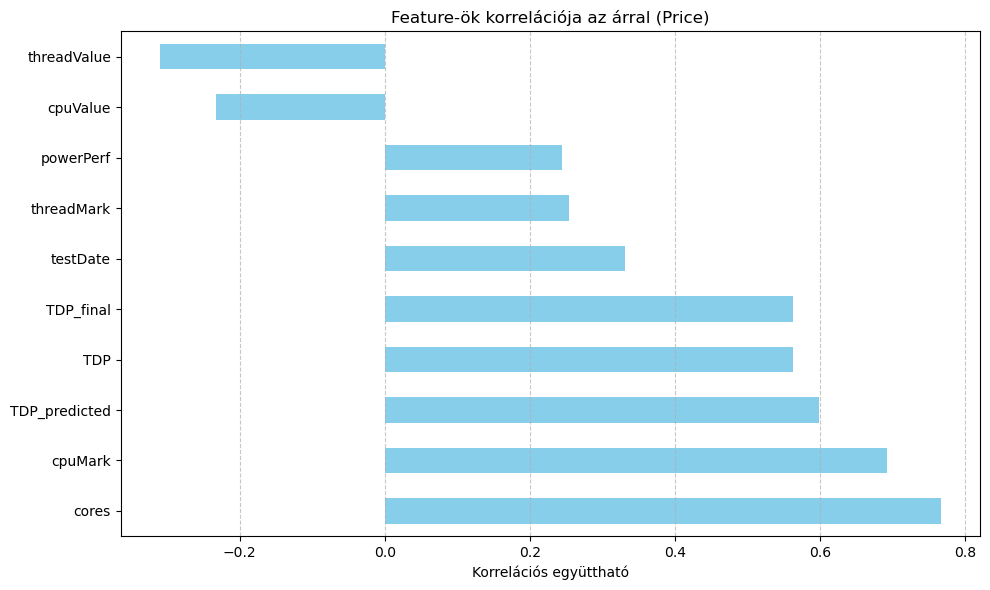

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Használjuk a korábban elmentett kiegészített adathalmazt
df_viz = pd.get_dummies(df_final_export, columns=['category'], prefix='cat')

# Numerikus korrelációk kiszámítása
numeric_df = df_viz.select_dtypes(include=[np.number])
price_correlations = numeric_df.corr()['price'].sort_values(ascending=False)

# Vizualizáció 1: Oszlopdiagram a Price korrelációiról
plt.figure(figsize=(10, 6))
price_correlations.drop('price').plot(kind='barh', color='skyblue')
plt.title('Feature-ök korrelációja az árral (Price)')
plt.xlabel('Korrelációs együttható')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
import numpy as np

# Adatok előkészítése: csak azokat a sorokat tartjuk meg, ahol van price
df_price_reg = df_final_export.dropna(subset=['price', 'cpuMark', 'threadMark', 'TDP', 'powerPerf', 'cores', 'testDate', 'category']).copy()

y_price = df_price_reg['price']

# 1. Modell feature-jei: cpuMark+threadMark+TDP+PowerPerf+cores+testDate+category
X_price1 = pd.get_dummies(df_price_reg[['cpuMark', 'threadMark', 'TDP', 'powerPerf', 'cores', 'testDate', 'category']], columns=['category'], drop_first=True)

# 2. Modell feature-jei: cpuMark+threadMark+TDP+cores+testDate+category (powerPerf nélkül)
X_price2 = pd.get_dummies(df_price_reg[['cpuMark', 'threadMark', 'TDP', 'cores', 'testDate', 'category']], columns=['category'], drop_first=True)

# Tanító és teszt halmazok (a target y_price alapján)
X_price1_train, X_price1_test, y_price_train, y_price_test = train_test_split(X_price1, y_price, test_size=0.2, random_state=42)
X_price2_train, X_price2_test, _, _ = train_test_split(X_price2, y_price, test_size=0.2, random_state=42)

# Modellek tanítása
model_price1 = LinearRegression().fit(X_price1_train, y_price_train)
model_price2 = LinearRegression().fit(X_price2_train, y_price_train)

# Predikciók
y_price_pred1 = model_price1.predict(X_price1_test)
y_price_pred2 = model_price2.predict(X_price2_test)

# Eredmények
results_price = pd.DataFrame({
    'Metric': ['RMSE', 'R2 Score'],
    'Modell 1 (PowerPerf-fel)': [np.sqrt(mean_squared_error(y_price_test, y_price_pred1)), r2_score(y_price_test, y_price_pred1)],
    'Modell 2 (PowerPerf nélkül)': [np.sqrt(mean_squared_error(y_price_test, y_price_pred2)), r2_score(y_price_test, y_price_pred2)]
})

display(results_price)

,Metric,Modell 1 (PowerPerf-fel),Modell 2 (PowerPerf nélkül)
0,RMSE,607.795739,607.777948
1,R2 Score,0.474907,0.474938


In [18]:
# 1. Feature-ök kiválasztása és dummy változók létrehozása
features = ['cpuMark', 'threadMark', 'TDP', 'powerPerf', 'cores', 'testDate', 'category']

# Tanító készlet: ahol van ár és minden feature megvan
df_price_train = df_final_export.dropna(subset=['price'] + features).copy()
X_train = pd.get_dummies(df_price_train[features], columns=['category'])
y_train = df_price_train['price']

# 2. Modell tanítása (Random Forest volt a legjobb korábban)
best_model = RandomForestRegressor(n_estimators=100, random_state=42)
best_model.fit(X_train, y_train)

# 3. Predikció azokra a sorokra, ahol hiányzik az ár
df_to_predict = df_final_export[df_final_export['price'].isnull() & df_final_export[features].notnull().all(axis=1)].copy()

if not df_to_predict.empty:
    X_missing = pd.get_dummies(df_to_predict[features], columns=['category'])
    # Biztosítjuk az oszlopok egyezőségét a tanító készlettel
    X_missing = X_missing.reindex(columns=X_train.columns, fill_value=0)
    
    predicted_prices = best_model.predict(X_missing)
    # Értékek beírása az eredeti (vagy másolt) DataFrame-be
    df_final_export.loc[df_to_predict.index, 'price'] = predicted_prices.round(2)

# 4. Mentés CSV fájlba
df_final_export.to_csv('../data/processed/CPU_benchmark_v4_price.csv', index=False)


print(f"Hiányzó árak pótolva: {len(df_to_predict)} sorban.")
print("Az adathalmaz elmentve: /content/CPU_benchmark_v4_price.csv")
display(df_final_export[['cpuName', 'cpuMark', 'price']].head(10))

Hiányzó árak pótolva: 1858 sorban.
Az adathalmaz elmentve: /content/CPU_benchmark_v4_price.csv


,cpuName,cpuMark,price
0,AMD Ryzen Threadripper PRO 5995WX,108822,6992.50
1,AMD EPYC 7763,88338,7299.99
2,AMD EPYC 7J13,86006,7041.09
3,AMD EPYC 7713,85861,7060.00
4,AMD Ryzen Threadripper PRO 3995WX,83971,6807.98
5,AMD Ryzen Threadripper 3990X,81568,8399.69
6,AMD Ryzen Threadripper PRO 5975WX,80842,5619.18
7,AMD EPYC 7B13,77460,6150.90
8,AMD EPYC 7643,76455,5424.99
9,AMD EPYC 7702,71646,4000.00


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import pandas as pd
import numpy as np

# 1. Alapadatok előkészítése és PowerPerf újraszámolása
df_pp_reg = df_final_export.copy()
df_pp_reg['powerPerf'] = (df_pp_reg['cpuMark'] / df_pp_reg['TDP']).round(2)

# 2. Adatszivárgás elkerülése: cpuMark és TDP eldobása
# Csak a maradék releváns feature-öket tartjuk meg
features = ['threadMark', 'cores', 'testDate', 'category', 'price']
df_model_data = df_pp_reg.dropna(subset=['powerPerf'] + features).copy()

X = pd.get_dummies(df_model_data[features], columns=['category'])
y = df_model_data['powerPerf']

# Tanító és teszt halmazok
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modellek definiálása
models = {
    'Linear': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42)
}

pp_results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    pp_results.append({'Modell': name, 'RMSE': rmse, 'MAE': mae, 'R2 Score': r2})

# Eredmények megjelenítése
pp_results_df = pd.DataFrame(pp_results).sort_values(by='R2 Score', ascending=False)
display(pp_results_df)

print("\n--- A modell által használt jellemzők (leakage nélkül) ---")
print(X.columns.tolist())

NameError: name 'mean_squareA_error' is not defined